# Supermarket sample (Kaggle) — Impact Split with step trace

This notebook loads [Sample Supermarket](https://www.kaggle.com/datasets/bravehart101/sample-supermarket-dataset) via `kagglehub`, fits `ImpactSplitter` with `trace=True`, and prints intermediate tables so you can confirm the algorithm behaves as expected.

## Prerequisites

- Install project deps: `pip install -r requirements.txt` (includes `kagglehub`).
- **Kaggle credentials:** for downloads, configure the Kaggle API (e.g. `~/.kaggle/kaggle.json` from your Kaggle account **Account → API → Create New Token**) or run `kagglehub.login()` once in an interactive session. See [kagglehub authentication](https://github.com/Kaggle/kagglehub#authentication).
- Target Python **3.13.x** as in `pyproject.toml`.

In [11]:
%matplotlib inline

from pathlib import Path

import kagglehub
import pandas as pd

from impact_split import ImpactSplitter

DATASET_SLUG = "bravehart101/sample-supermarket-dataset"
root = Path(kagglehub.dataset_download(DATASET_SLUG))
csv_paths = sorted(root.rglob("*.csv"))
assert csv_paths, f"No CSV under {root}"
csv_path = csv_paths[0]
print("Using:", csv_path)

Using: /Users/juedimyroeugenio/.cache/kagglehub/datasets/bravehart101/sample-supermarket-dataset/versions/1/SampleSuperstore.csv


In [12]:
df = pd.read_csv(csv_path)
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## Build `X` and `y`

- **y:** `Profit` (additive contribution at row level).
- **X:** a few categorical columns with moderate cardinality so the tree stays readable. City / postal code are omitted here.

In [13]:
feature_cols = ["Region", "Category", "Segment", "Ship Mode"]
missing = [c for c in feature_cols + ["Profit"] if c not in df.columns]
if missing:
    raise ValueError(f"Unexpected columns: {missing}")

X = df[feature_cols].astype(str)
y = df["Profit"].astype(float)
mask = y.notna() & X.notna().all(axis=1)
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)

print("rows:", len(X), "y.sum():", y.sum())
X.head(), y.head()

rows: 9994 y.sum(): 286397.0217


(  Region         Category    Segment       Ship Mode
 0  South        Furniture   Consumer    Second Class
 1  South        Furniture   Consumer    Second Class
 2   West  Office Supplies  Corporate    Second Class
 3  South        Furniture   Consumer  Standard Class
 4  South  Office Supplies   Consumer  Standard Class,
 0     41.9136
 1    219.5820
 2      6.8714
 3   -383.0310
 4      2.5164
 Name: Profit, dtype: float64)

In [14]:
model = ImpactSplitter(
    delta_pct=0.05,
    min_global_impact_pct=0.01,
    max_depth=4,
)
model.fit(X, y, trace=True)
print("trace steps:", len(model.fit_trace_))

trace steps: 1


## Node-level thresholds and sums

At each node, `delta_nominal = delta_pct * V_node` (reference scale). **Assignment** uses `delta` and `delta_neg` from the trace: with default `neutral_root=True`, the **root** (`depth == 0`) uses `delta = 0`, so **P** if `S_cat > 0`, **N** if `S_cat < 0`, **neutral** if `S_cat == 0`. Child nodes use `delta = delta_nominal` (same rule as before: **P** / **N** / **neutral** vs ±`delta`). The table lists `delta_nominal`, assignment boundaries, and node mass for every trace step; category rows are in `category_tables`.

In [15]:
summary_rows = []
for step in model.fit_trace_:
    nb = step["neutral_band"]
    summary_rows.append(
        {
            "node_id": step["node_id"],
            "depth": step["depth"],
            "n_samples": step["n_samples"],
            "total_sum": step["total_sum"],
            "V_node": step["V_node"],
            "s_node_p": step["s_node_p"],
            "s_node_n": step["s_node_n"],
            "delta_pct": step["delta_pct"],
            "delta_nominal": step.get("delta_nominal", step["V_node"] * step["delta_pct"]),
            "delta": step["delta"],
            "delta_neg": step["delta_neg"],
            "neutral_low": nb["low"],
            "neutral_high": nb["high"],
            "action": step["action"],
            "stop_reason": step.get("stop_reason"),
        }
    )
pd.DataFrame(summary_rows)

KeyError: 'delta_nominal'

## Trace: one row per decision node (pre-order)

Each entry includes `delta_nominal`, assignment boundaries (`delta`, `delta_neg`, `neutral_band`), node masses (`V_node`, `s_node_p`, `s_node_n`, `total_sum`), global materiality ratios, candidate gains per feature, and (when the node splits) category tables for every evaluated feature (`S_cat` vs the step's assignment ±`delta`).

In [ ]:
trace_rows = []
for step in model.fit_trace_:
    trace_rows.append(
        {
            "node_id": step["node_id"],
            "depth": step["depth"],
            "n_samples": step["n_samples"],
            "action": step["action"],
            "stop_reason": step.get("stop_reason"),
            "delta": step["delta"],
            "materiality_pass": step["materiality_pass"],
            "chosen_feature": step.get("chosen_feature"),
            "chosen_gain": step.get("chosen_gain"),
        }
    )
pd.DataFrame(trace_rows)

,node_id,depth,n_samples,action,stop_reason,delta,materiality_pass,chosen_feature,chosen_gain
0,node_0,0,9994,leaf,no_split,29932.979655,True,None,None


In [ ]:
shown = 0
for step in model.fit_trace_:
    if step["action"] != "split":
        continue
    feat = step["chosen_feature"]
    print("=" * 80)
    print(step["node_id"], "depth", step["depth"], "split /on", feat)
    cg = pd.DataFrame(step["candidate_gains"])
    print("Candidate gains:")
    display(cg)
    if feat and feat in step.get("category_tables", {}):
        print("Category assignment (chosen feature):")
        display(pd.DataFrame(step["category_tables"][feat]))
    shown += 1
    if shown >= 3:
        print("... (truncated; increase `shown` limit to inspect more splits)")
        break

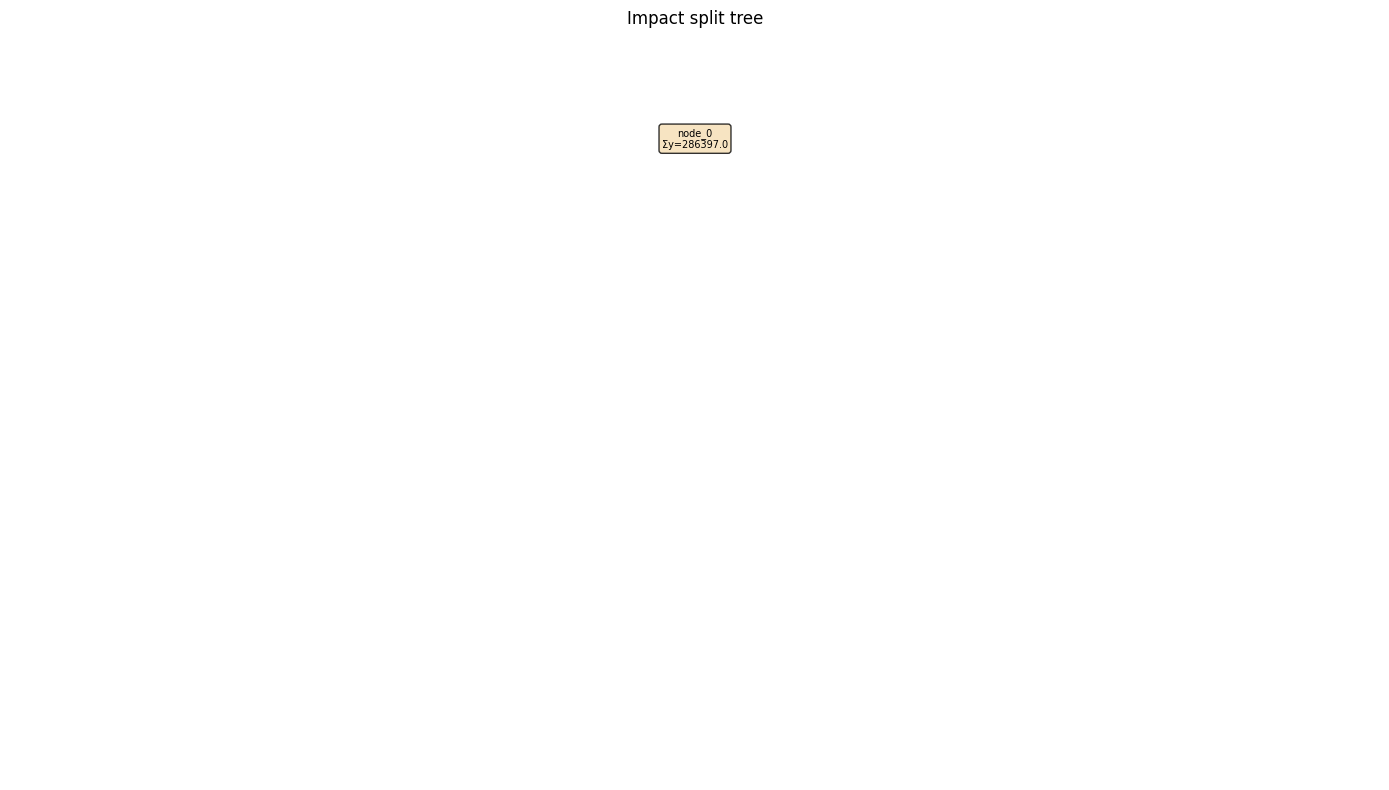

In [ ]:
model.plot_tree(figsize=(14, 8))

`plot_tree` renders one matplotlib figure for the fitted tree.

In [ ]:
segments = model.get_impact_segments()
segments.head(15)

,path,total_sum,n_samples,node_id
0,root,286397.0217,9994,node_0


## Sanity checks

- Terminal segments partition the rows: the sum of segment `total_sum` should match the global sum of `y` (each row assigned to exactly one leaf).
- Root trace step should show `depth == 0` and global ratios `pos_ratio` / `neg_ratio` consistent with the node’s share of positive vs negative mass.
- Tightening `min_global_impact_pct` or `delta_pct` should change how soon nodes stop splitting (`stop_reason` in the trace table).

In [ ]:
seg_sum = segments["total_sum"].sum()
y_sum = float(y.sum())
print("sum(y):", y_sum)
print("sum(segment totals):", seg_sum)
assert abs(seg_sum - y_sum) < 1e-3 * max(1.0, abs(y_sum)), "Segment totals should match global y sum"

sum(y): 286397.0217
sum(segment totals): 286397.0217
